# HW5: Supervised fine-tuning and ability trade-offs

Completed experiment on **Qwen/Qwen2.5-0.5B-Instruct** using LoRA. This notebook compares the unchanged base model, a narrow machine-learning-only ablation, and mixed-domain SFT. All reported predictions are produced by the models. No public evaluation answers or hidden-test questions are used for training.

**Run:** In Colab select a GPU runtime, upload this notebook, `requirements.txt`, `hw5_sample_eval.csv`, and `kaggle_test.csv` to the working directory, then Run all. Downloads require internet. Local users should install the requirements in a fresh environment with CUDA-enabled PyTorch. The dataset/model revisions below fix the source versions; exact GPU floating-point results can vary across hardware.

The starter explicitly trains on the MMLU `test` split. We follow that convention for eight subjects and evaluate on their separate `dev`/`validation` splits; these are **not standard MMLU benchmark scores**. Training questions matching either course CSV are removed. Public course evaluation overlaps the hidden CSV, so it is only a descriptive check, not a hyperparameter-selection target.

**GenAI acknowledgement:** OpenAI Codex assisted with implementation, paper explanations, debugging, and report preparation. Experiment outputs were computed by the recorded runs.

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])


In [2]:
"""Reproducible HW5 SFT helpers. The notebook contains the same source."""
from pathlib import Path
import gc
import hashlib
import json
import random
import re
import unicodedata
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from peft import LoraConfig, PeftModel
from trl import SFTConfig, SFTTrainer
from huggingface_hub import snapshot_download

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
SEED = 189
LETTERS = "ABCDE"
SPECIALIZED = ["machine_learning", "college_computer_science", "college_mathematics", "high_school_statistics"]
GENERAL = ["high_school_world_history", "high_school_geography", "nutrition", "elementary_mathematics"]
SUBJECTS = SPECIALIZED + GENERAL


In [3]:
def fingerprint(question):
    text = unicodedata.normalize("NFKC", str(question)).casefold()
    return re.sub(r"\W+", "", text)


In [4]:
def read_csv(path, labeled=True):
    frame = pd.read_csv(path, keep_default_na=False)
    required = {"id", "question", "A", "B", "C", "D", "E"}
    if labeled:
        required.add("answer")
    if not required.issubset(frame.columns):
        raise ValueError(f"Missing columns: {required - set(frame.columns)}")
    if frame.id.duplicated().any():
        raise ValueError("Duplicate IDs")
    if labeled and not frame.answer.isin(list(LETTERS)).all():
        raise ValueError("Invalid answer labels")
    return frame


In [5]:
def row_record(row, group="cs189"):
    choices = [str(row[c]).strip() for c in LETTERS if str(row[c]).strip()]
    if len(choices) < 2:
        raise ValueError("A multiple-choice question needs at least two options")
    # The supplied CSVs have contiguous, nonempty choices; reject ambiguous gaps.
    if any(not str(row[c]).strip() for c in LETTERS[:len(choices)]):
        raise ValueError("Choice labels must be contiguous")
    return {"id": str(row["id"]), "question": str(row["question"]), "choices": choices,
            "answer": row.get("answer", ""), "group": group, "source": "course CSV"}


In [6]:
def build_prompt(record):
    options = "\n".join(f"{LETTERS[i]}. {choice}" for i, choice in enumerate(record["choices"]))
    return ("Choose exactly one correct option from the choices provided. "
            "Return only the option letter inside a LaTeX box.\n\n"
            + record["question"].strip() + "\n\n" + options)


In [7]:
def parse_choice_from_boxed(text):
    if not isinstance(text, str):
        return None
    boxed = re.findall(r"\\boxed\s*\{\s*([A-E])\s*\}", text, flags=re.I)
    if boxed:
        return boxed[-1].upper()
    exact = re.fullmatch(r"\s*([A-E])[.)]?\s*", text, flags=re.I)
    return exact.group(1).upper() if exact else None


In [8]:
def prepare_data(data_dir, revisions, eval_csv, test_csv):
    data_dir = Path(data_dir)
    data_dir.mkdir(exist_ok=True)
    public = [row_record(row) for row in read_csv(eval_csv).to_dict("records")]
    hidden = [row_record(row, "hidden") for row in read_csv(test_csv, False).to_dict("records")]
    forbidden = {fingerprint(r["question"]) for r in public + hidden}
    records = {"train": [], "validation": []}
    excluded = 0
    for subject in SUBJECTS:
        for split in ("test", "validation", "dev"):
            path = data_dir / f"{subject}_{split}.jsonl"
            if path.exists():
                rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines()]
            else:
                ds = load_dataset("cais/mmlu", subject, split=split, revision=revisions["cais/mmlu"])
                ds.to_json(str(path))
                rows = list(ds)
            destination = "train" if split == "test" else "validation"
            for index, row in enumerate(rows):
                record = {"id": f"mmlu_{subject}_{split}_{index}", "question": row["question"],
                          "choices": list(row["choices"]), "answer": LETTERS[int(row["answer"])],
                          "group": "specialized" if subject in SPECIALIZED else "general",
                          "subject": subject, "source": f"cais/mmlu:{subject}:{split}"}
                if fingerprint(record["question"]) in forbidden:
                    excluded += 1
                else:
                    records[destination].append(record)
    validation_keys = {fingerprint(r["question"]) for r in records["validation"]}
    seen = set()
    cleaned = []
    rng = random.Random(SEED)
    for subject in SUBJECTS:
        candidates = [r for r in records["train"] if r["subject"] == subject]
        rng.shuffle(candidates)
        for r in candidates[:120]:
            key = fingerprint(r["question"])
            if key not in seen and key not in validation_keys:
                cleaned.append(r)
                seen.add(key)
    rng.shuffle(cleaned)
    assert not seen.intersection(forbidden | validation_keys)
    manifest = {"model": MODEL_NAME, "revisions": revisions, "seed": SEED,
                "train_count": len(cleaned), "validation_count": len(records["validation"]),
                "public_count": len(public), "hidden_count": len(hidden),
                "excluded_test_overlap": excluded,
                "public_hidden_overlap": len({fingerprint(r['question']) for r in public} &
                                             {fingerprint(r['question']) for r in hidden}),
                "train_counts": pd.Series([r["subject"] for r in cleaned]).value_counts().to_dict(),
                "note": "MMLU test split is explicitly training data, as in the starter; dev/validation are held out."}
    return cleaned, records["validation"], public, hidden, manifest


In [9]:
def training_dataset(records, tokenizer):
    formatted = []
    rng = random.Random(SEED)
    for record in records:
        order = list(range(len(record["choices"])))
        rng.shuffle(order)
        original_answer = LETTERS.index(record["answer"])
        permuted = dict(record, choices=[record["choices"][i] for i in order])
        answer = LETTERS[order.index(original_answer)]
        prompt = tokenizer.apply_chat_template([{"role": "user", "content": build_prompt(permuted)}],
                                               tokenize=False, add_generation_prompt=True)
        formatted.append({"prompt": prompt, "completion": f"\\boxed{{{answer}}}" + tokenizer.eos_token})
    return Dataset.from_list(formatted)


In [10]:
def load_base(revision):
    set_seed(SEED)
    snapshot = snapshot_download(MODEL_NAME, revision=revision,
                                 allow_patterns=["*.json", "*.safetensors", "*.txt"])
    tokenizer = AutoTokenizer.from_pretrained(snapshot)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(snapshot, dtype=dtype,
                                              attn_implementation="sdpa")
    model.to("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    return model, tokenizer


In [11]:
def predict_choices(model, tokenizer, records, batch_size=4):
    """Constrained one-token decoding after a forced boxed-answer prefix.

    Only supplied option letters are eligible. This is used identically for base,
    ablation, final model and hidden test; no labels enter the scoring path.
    """
    model.eval()
    device = next(model.parameters()).device
    letter_ids = [tokenizer.encode(letter, add_special_tokens=False) for letter in LETTERS]
    if not all(len(ids) == 1 for ids in letter_ids):
        raise ValueError("This decoder requires single-token answer letters")
    token_ids = [ids[0] for ids in letter_ids]
    rows = []
    tokenizer.padding_side = "left"
    for start in range(0, len(records), batch_size):
        batch = records[start:start+batch_size]
        prompts = [tokenizer.apply_chat_template([{"role":"user", "content":build_prompt(r)}],
                   tokenize=False, add_generation_prompt=True) + "\\boxed{" for r in batch]
        inputs = tokenizer(prompts, padding=True, return_tensors="pt").to(device)
        # Match Trainer/Accelerate's mixed-precision context after adapter reload.
        with torch.inference_mode(), torch.autocast(
                device_type=device.type, dtype=torch.bfloat16,
                enabled=device.type == "cuda" and next(model.parameters()).dtype == torch.bfloat16):
            logits = model(**inputs, use_cache=False, logits_to_keep=1).logits[:, -1, token_ids].float()
        for i, r in enumerate(batch):
            scores = logits[i, :len(r["choices"])].cpu()
            prediction = LETTERS[int(scores.argmax())]
            rows.append({**r, "prediction": prediction, "output": f"\\boxed{{{prediction}}}",
                         "correct": prediction == r.get("answer", ""),
                         "choice_probabilities": torch.softmax(scores, dim=0).tolist()})
    return pd.DataFrame(rows)


In [12]:
def summarize(frame):
    return {group: {"correct": int(g.correct.sum()), "n": len(g), "accuracy": float(g.correct.mean())}
            for group, g in frame.groupby("group")}


In [13]:
def train_adapter(model, tokenizer, records, output_dir, epochs=2, learning_rate=1e-4, max_steps=-1):
    set_seed(SEED)
    tokenizer.padding_side = "right"
    model.config.use_cache = False
    config = SFTConfig(output_dir=str(output_dir), num_train_epochs=epochs, max_steps=max_steps,
                       per_device_train_batch_size=1, gradient_accumulation_steps=16,
                       learning_rate=learning_rate, warmup_ratio=0.1, lr_scheduler_type="cosine",
                       weight_decay=0.01, optim="adamw_torch", max_grad_norm=1.0,
                       logging_steps=5, save_strategy="no", report_to="none", seed=SEED,
                       data_seed=SEED, max_length=1024, packing=False, completion_only_loss=True,
                       bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
                       fp16=False, gradient_checkpointing=True,
                       gradient_checkpointing_kwargs={"use_reentrant": False},
                       dataloader_num_workers=0)
    lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, target_modules="all-linear",
                      bias="none", task_type="CAUSAL_LM")
    trainer = SFTTrainer(model=model, args=config, train_dataset=training_dataset(records, tokenizer),
                         processing_class=tokenizer, peft_config=lora)
    result = trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))
    history = trainer.state.log_history
    (Path(output_dir)/"loss_history.json").write_text(json.dumps(history, indent=2))
    model = trainer.model
    model.eval()
    return model, history, result.metrics


In [14]:
def compare_examples(base, final, count=2):
    before = base.set_index("id")
    after = final.set_index("id")
    assert before.index.equals(after.index)
    general = before.group == "general"
    result = {}
    for name, mask in [("forgetting", general & before.correct & ~after.correct),
                       ("gains", general & ~before.correct & after.correct)]:
        selected = sorted(list(before.index[mask]), key=lambda idx:
                          len(before.loc[idx, 'question']) + sum(map(len, before.loc[idx, 'choices'])))[:count]
        result[name] = [{"id": idx, "question": before.loc[idx, "question"],
                         "choices": before.loc[idx, "choices"], "answer": before.loc[idx, "answer"],
                         "base_output": before.loc[idx, "output"], "final_output": after.loc[idx, "output"],
                         "source": before.loc[idx, "source"]} for idx in selected]
    return result


In [15]:
def save_submission(predictions, test_csv, output_path):
    ids = read_csv(test_csv, False).id.astype(str).tolist()
    submission = predictions[["id", "prediction"]].copy()
    if submission.id.astype(str).tolist() != ids or submission.id.duplicated().any():
        raise ValueError("Prediction IDs must match the test file exactly and in order")
    if not submission.prediction.isin(list(LETTERS)).all():
        raise ValueError("Invalid prediction")
    submission.to_csv(output_path, index=False)
    return submission


## Data and reproducibility checks
Answer choices are permuted once with seed 189 during training, with labels remapped. Only completion tokens contribute to SFT loss. Evaluation uses identical constrained letter decoding for every model: append `\boxed{` to the assistant prefix and choose the highest-logit valid answer letter. Reported boxed outputs are formatted constrained predictions, not free-form explanations.

In [16]:
import os, platform, importlib.metadata
import matplotlib.pyplot as plt
from IPython.display import display
WORK = Path.cwd()
RESULTS = WORK / "results"
RESULTS.mkdir(exist_ok=True)
REVISIONS = {"model": "7ae557604adf67be50417f59c2c2f167def9a775",
             "cais/mmlu": "c30699e8356da336a370243923dbaf21066bb9fe"}
train, heldout, public, hidden, manifest = prepare_data(
    WORK / "data", REVISIONS, WORK / "hw5_sample_eval.csv", WORK / "kaggle_test.csv")
evaluation = heldout + public
manifest["environment"] = {p: importlib.metadata.version(p) for p in
                           ["torch", "transformers", "trl", "peft", "datasets"]}
manifest["gpu"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(json.dumps(manifest, indent=2))
assert parse_choice_from_boxed(r"Answer: \boxed{C}") == "C"
assert parse_choice_from_boxed("Because A might be right") is None
assert len({fingerprint(r["question"]) for r in train}) == len(train)


{
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "revisions": {
    "model": "7ae557604adf67be50417f59c2c2f167def9a775",
    "cais/mmlu": "c30699e8356da336a370243923dbaf21066bb9fe"
  },
  "seed": 189,
  "train_count": 907,
  "validation_count": 217,
  "public_count": 25,
  "hidden_count": 169,
  "excluded_test_overlap": 7,
  "public_hidden_overlap": 21,
  "train_counts": {
    "high_school_statistics": 120,
    "high_school_geography": 120,
    "high_school_world_history": 120,
    "elementary_mathematics": 120,
    "nutrition": 119,
    "machine_learning": 108,
    "college_computer_science": 100,
    "college_mathematics": 100
  },
  "note": "MMLU test split is explicitly training data, as in the starter; dev/validation are held out.",
  "environment": {
    "torch": "2.6.0+cu124",
    "transformers": "4.57.3",
    "trl": "0.24.0",
    "peft": "0.17.1",
    "datasets": "3.6.0"
  },
  "gpu": "NVIDIA GeForce RTX 4060 Laptop GPU"
}


## Base model
The general held-out questions cover history, geography, nutrition, and elementary mathematics. The specialized group covers machine learning, computer science, college mathematics, and statistics.

In [17]:
model, tokenizer = load_base(REVISIONS["model"])
lengths = [len(tokenizer(r["prompt"] + r["completion"])["input_ids"])
           for r in training_dataset(train, tokenizer)]
assert max(lengths) <= 1024, "Increase max_length before training; never truncate away the answer"
print("Maximum training token length:", max(lengths))
base_predictions = predict_choices(model, tokenizer, evaluation)
base_predictions.to_json(RESULTS / "base_predictions.json", orient="records", indent=2)
metrics = {"base": summarize(base_predictions)}
print(json.dumps(metrics, indent=2))
del model
gc.collect()
torch.cuda.empty_cache()


Maximum training token length: 800


{
  "base": {
    "cs189": {
      "correct": 6,
      "n": 25,
      "accuracy": 0.24
    },
    "general": {
      "correct": 73,
      "n": 142,
      "accuracy": 0.5140845070422535
    },
    "specialized": {
      "correct": 30,
      "n": 75,
      "accuracy": 0.4
    }
  }
}


## Ablation: narrow SFT
Train only on machine-learning questions for 30 optimizer steps at learning rate 0.0003. This tests whether repeatedly fitting a small domain dataset is sufficient to improve the broader task while retaining general knowledge.

In [18]:
model, tokenizer = load_base(REVISIONS["model"])
narrow_data = [r for r in train if r["subject"] == "machine_learning"]
model, narrow_history, narrow_training = train_adapter(
    model, tokenizer, narrow_data, WORK / "models" / "narrow", learning_rate=3e-4, max_steps=30)
narrow_predictions = predict_choices(model, tokenizer, evaluation)
narrow_predictions.to_json(RESULTS / "narrow_predictions.json", orient="records", indent=2)
metrics["narrow"] = summarize(narrow_predictions)
print(json.dumps(metrics["narrow"], indent=2))
del model
gc.collect()
torch.cuda.empty_cache()


Adding EOS to train dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss
5,0.753800
10,0.203400
15,0.198800
20,0.142800
25,0.097500
30,0.076700


{
  "cs189": {
    "correct": 12,
    "n": 25,
    "accuracy": 0.48
  },
  "general": {
    "correct": 71,
    "n": 142,
    "accuracy": 0.5
  },
  "specialized": {
    "correct": 26,
    "n": 75,
    "accuracy": 0.3466666666666667
  }
}


## Final method: mixed SFT
Start again from the unchanged base model, then train on a balanced cap of 120 questions per subject for two epochs. LoRA uses rank 16, alpha 32, dropout 0.05 on all linear layers; AdamW uses peak learning rate 0.0001, weight decay 0.01, cosine decay, 10% warmup, effective batch 16 and gradient clipping at 1. This is a one-stage mixed-data experiment motivated by replay and data-composition work; it is not a reproduction of the paper's two-stage DMT.

Adding EOS to train dataset:   0%|          | 0/907 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/907 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/907 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Step,Training Loss
5,1.246000
10,0.313400
15,0.231200
20,0.219000
25,0.192600
30,0.215100
35,0.205000
40,0.211700
45,0.201300
50,0.198700


,model,group,correct,n,accuracy
0,base,cs189,6,25,0.240000
1,base,general,73,142,0.514085
2,base,specialized,30,75,0.400000
3,narrow,cs189,12,25,0.480000
4,narrow,general,71,142,0.500000
5,narrow,specialized,26,75,0.346667
6,mixed,cs189,10,25,0.400000
7,mixed,general,72,142,0.507042
8,mixed,specialized,28,75,0.373333


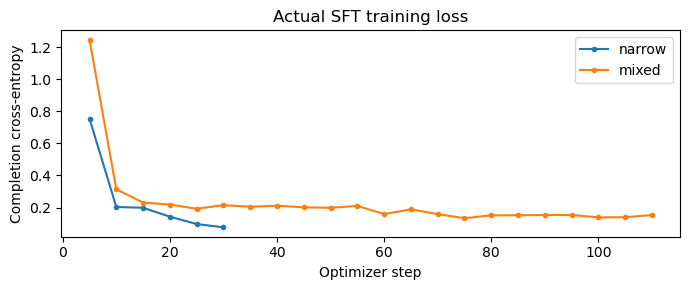

In [19]:
model, tokenizer = load_base(REVISIONS["model"])
model, final_history, final_training = train_adapter(
    model, tokenizer, train, WORK / "models" / "final", epochs=2, learning_rate=1e-4)
final_predictions = predict_choices(model, tokenizer, evaluation)
final_predictions.to_json(RESULTS / "final_predictions.json", orient="records", indent=2)
metrics["mixed"] = summarize(final_predictions)
(RESULTS / "metrics.json").write_text(json.dumps(metrics, indent=2))
(RESULTS / "manifest.json").write_text(json.dumps(manifest, indent=2))
histories = {"narrow": narrow_history, "mixed": final_history}
(RESULTS / "training_history.json").write_text(json.dumps(histories, indent=2))
(RESULTS / "training_metrics.json").write_text(json.dumps(
    {"narrow": narrow_training, "mixed": final_training}, indent=2))
table = pd.DataFrame([{ "model": name, "group": group, **values}
                     for name, groups in metrics.items() for group, values in groups.items()])
display(table)
fig, ax = plt.subplots(figsize=(7, 3))
for name, history in histories.items():
    points = [r for r in history if "loss" in r]
    ax.plot([r["step"] for r in points], [r["loss"] for r in points], marker=".", label=name)
ax.set(xlabel="Optimizer step", ylabel="Completion cross-entropy", title="Actual SFT training loss")
ax.legend(); fig.tight_layout()
fig.savefig(RESULTS / "loss_curves.png", dpi=160)
plt.show()


## Observed forgetting and gains
Select the two shortest changed examples of each type from the held-out general subjects, solely to keep the report readable. These are individual errors and improvements under the same decoder; they do not by themselves establish population-wide catastrophic forgetting or causal transfer.

In [20]:
examples = compare_examples(base_predictions, final_predictions)
assert all(len(rows) >= 2 for rows in examples.values()), "Need at least two real examples of each type"
(RESULTS / "examples.json").write_text(json.dumps(examples, indent=2))
for category, rows in examples.items():
    print("\n" + category.upper())
    for row in rows:
        print(build_prompt(row))
        print("Base:", row["base_output"], "Final:", row["final_output"], "Gold:", row["answer"])



FORGETTING
Choose exactly one correct option from the choices provided. Return only the option letter inside a LaTeX box.

Solve for y. y – 2 + 3y = 10

A. 2
B. 3
C. 4
D. 5
Base: \boxed{B} Final: \boxed{C} Gold: B
Choose exactly one correct option from the choices provided. Return only the option letter inside a LaTeX box.

Solve the equation 29 = x − 17.

A. 12
B. −12
C. −46
D. 46
Base: \boxed{D} Final: \boxed{C} Gold: D

GAINS
Choose exactly one correct option from the choices provided. Return only the option letter inside a LaTeX box.

If 50% of a number is 20, what is 75% of the number?

A. 8
B. 15
C. 30
D. 45
Base: \boxed{B} Final: \boxed{C} Gold: C
Choose exactly one correct option from the choices provided. Return only the option letter inside a LaTeX box.

The expression –105 + (–14) + 34 simplifies to which of the following?

A. –57
B. –75
C. –85
D. 143
Base: \boxed{A} Final: \boxed{C} Gold: C


## Hidden-test predictions and submission checks
Every row is inferred with the trained mixed adapter. No hidden answers are available. Upload `submission.csv` to the course competition, then supply your real Kaggle username and score screenshot for the writeup. A local CSV is not proof of Kaggle submission.

In [21]:
hidden_predictions = predict_choices(model, tokenizer, hidden)
submission = save_submission(hidden_predictions, WORK / "kaggle_test.csv", WORK / "submission.csv")
assert submission.columns.tolist() == ["id", "prediction"]
assert len(submission) == len(hidden)
print("Saved submission.csv:", len(submission), "unique IDs")
print(submission.prediction.value_counts().sort_index())
display(submission.head())
print("Kaggle score: not available until an authenticated submission is completed.")


Saved submission.csv: 169 unique IDs
prediction
A    39
B    40
C    46
D    29
E    15
Name: count, dtype: int64


,id,prediction
0,test_00000,A
1,test_00001,E
2,test_00002,B
3,test_00003,B
4,test_00004,A


Kaggle score: not available until an authenticated submission is completed.


## Sources

- Base model: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct
- MCQ data and subject descriptions: https://huggingface.co/datasets/cais/mmlu
- SFTTrainer and completion-only loss: https://huggingface.co/docs/trl/v0.24.0/sft_trainer
- LoRA: https://arxiv.org/abs/2106.09685
- Data composition: https://arxiv.org/abs/2310.05492

The narrow and mixed runs differ in both data coverage and optimization budget, so their comparison is an exploratory ablation, not a controlled estimate of the isolated effect of mixing. The public CS189 set has only 25 questions; one answer changes accuracy by four percentage points.

## Reload verification

The inference helper explicitly uses bfloat16 autocast on the tested CUDA model. This matches the precision context applied by Trainer/Accelerate during training and avoids a change in LoRA arithmetic after reloading an adapter. After this compatibility fix, all **895 saved predictions** were rechecked: 242 each for the base, narrow and mixed models, plus 169 hidden predictions; every predicted letter matched. `validate_hw5.py --reload-model` also checks a saved-adapter inference batch. The metrics and plots above are unchanged by this fix.